In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATA_DIR = Path("traffic_sign")

TRAIN_CSV = DATA_DIR / "Train.csv"
TEST_CSV = DATA_DIR / "Test.csv"
META_CSV = DATA_DIR / "Meta.csv"

print("DATA_DIR ekziston:", DATA_DIR.exists())
print("Train.csv ekziston:", TRAIN_CSV.exists())
print("Test.csv ekziston:", TEST_CSV.exists())
print("Meta.csv ekziston:", META_CSV.exists())

DATA_DIR ekziston: True
Train.csv ekziston: True
Test.csv ekziston: True
Meta.csv ekziston: True


In [3]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
meta_df = pd.read_csv(META_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Meta shape:", meta_df.shape)

train_df.head()

Train shape: (39209, 8)
Test shape: (12630, 8)
Meta shape: (43, 5)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [4]:
print("Kolonat ne Train.csv:")
print(train_df.columns.tolist())

print("Vlera mungese ne train:")
print(train_df.isnull().sum())

print("Numri i klasave:", train_df['ClassId'].nunique())
print("Shperndarja e klasave:")
print(train_df['ClassId'].value_counts().sort_index())

Kolonat ne Train.csv:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Vlera mungese ne train:
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64
Numri i klasave: 43
Shperndarja e klasave:
ClassId
0      210
1     2220
2     2250
3     1410
4     1980
5     1860
6      420
7     1440
8     1410
9     1470
10    2010
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
21     330
22     390
23     510
24     270
25    1500
26     600
27     240
28     540
29     270
30     450
31     780
32     240
33     689
34     420
35    1200
36     390
37     210
38    2070
39     300
40     360
41     240
42     240
Name: count, dtype: int64


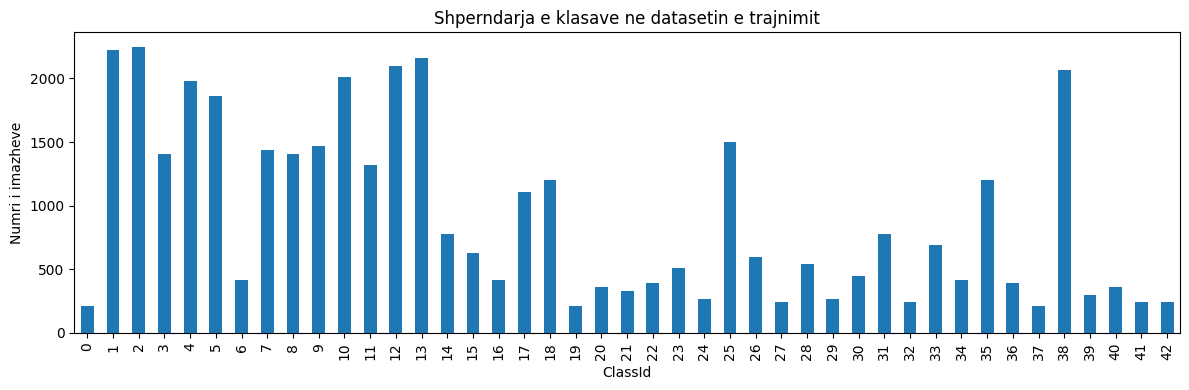

In [5]:
plt.figure(figsize=(12, 4))
train_df['ClassId'].value_counts().sort_index().plot(kind='bar')
plt.title('Shperndarja e klasave ne datasetin e trajnimit')
plt.xlabel('ClassId')
plt.ylabel('Numri i imazheve')
plt.tight_layout()
plt.show()

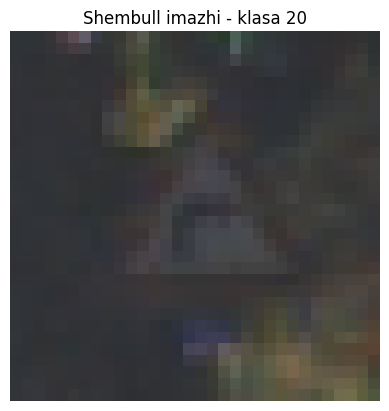

In [6]:
IMG_SIZE = 32

def load_image(relative_path, img_size=IMG_SIZE):
    image_path = DATA_DIR / relative_path
    image = Image.open(image_path).convert('RGB')
    image = image.resize((img_size, img_size))
    return np.array(image) / 255.0

sample_path = train_df.iloc[0]['Path']
sample_img = load_image(sample_path)

plt.imshow(sample_img)
plt.title(f"Shembull imazhi - klasa {train_df.iloc[0]['ClassId']}")
plt.axis('off')
plt.show()

In [7]:
USE_SUBSET = True
SUBSET_SIZE = 8000

if USE_SUBSET:
    train_work_df = train_df.sample(
        n=min(SUBSET_SIZE, len(train_df)),
        random_state=RANDOM_STATE
    ).reset_index(drop=True)
else:
    train_work_df = train_df.copy()

print("Numri i imazheve qe do perdoren:", len(train_work_df))
print("Numri i klasave:", train_work_df['ClassId'].nunique())

Numri i imazheve qe do perdoren: 8000
Numri i klasave: 43


In [8]:
X_images = np.array([load_image(path) for path in train_work_df['Path']])
y = train_work_df['ClassId'].values

print("Forma e X_images:", X_images.shape)
print("Forma e y:", y.shape)

Forma e X_images: (8000, 32, 32, 3)
Forma e y: (8000,)


In [9]:
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_images,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train_img.shape, y_train.shape)
print("Test:", X_test_img.shape, y_test.shape)

Train: (6400, 32, 32, 3) (6400,)
Test: (1600, 32, 32, 3) (1600,)


In [10]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat:", X_test_flat.shape)

X_train_flat: (6400, 3072)
X_test_flat: (1600, 3072)


In [11]:
pca = PCA(n_components=100, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("Forma pas PCA:", X_train_pca.shape)
print("Varianca e ruajtur nga PCA:", round(pca.explained_variance_ratio_.sum(), 4))

Forma pas PCA: (6400, 100)
Varianca e ruajtur nga PCA: 0.9464


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [13]:
results = []
trained_models = {}

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })
    trained_models[model_name] = model

    print(f"---- {model_name} ----")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1-score:", round(f1, 4))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return y_pred

In [14]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=3, scoring='f1_macro', n_jobs=-1)
knn_grid.fit(X_train_pca, y_train)

print("Parametrat me te mire per KNN:", knn_grid.best_params_)
y_pred_knn = evaluate_model('KNN + PCA', knn_grid.best_estimator_, X_train_pca, X_test_pca, y_train, y_test)


Parametrat me te mire per KNN: {'knn__n_neighbors': 3, 'knn__weights': 'distance'}
---- KNN + PCA ----
Accuracy: 0.7744
Precision: 0.802
Recall: 0.7661
F1-score: 0.7746
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.74      0.62      0.68        96
           2       0.81      0.59      0.68        92
           3       0.62      0.70      0.66        60
           4       0.69      0.86      0.76        86
           5       0.47      0.62      0.54        68
           6       0.65      0.76      0.70        17
           7       0.49      0.61      0.55        57
           8       0.58      0.86      0.69        59
           9       0.91      0.69      0.79        62
          10       0.81      0.82      0.81        72
          11       0.85      0.69      0.76        49
          12       0.93      0.87      0.90        93
          13       0.94      0.91      0.93        

In [15]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train_flat, y_train)

print("Parametrat me te mire per Random Forest:", rf_grid.best_params_)
y_pred_rf = evaluate_model('Random Forest', rf_grid.best_estimator_, X_train_flat, X_test_flat, y_train, y_test)


Parametrat me te mire per Random Forest: {'max_depth': None, 'n_estimators': 200}
---- Random Forest ----
Accuracy: 0.9175
Precision: 0.9461
Recall: 0.8851
F1-score: 0.9067
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.78      0.94      0.85        96
           2       0.78      0.88      0.83        92
           3       0.82      0.85      0.84        60
           4       0.88      0.95      0.92        86
           5       0.79      0.68      0.73        68
           6       0.94      1.00      0.97        17
           7       0.98      0.82      0.90        57
           8       0.94      0.81      0.87        59
           9       0.97      1.00      0.98        62
          10       0.97      0.96      0.97        72
          11       0.91      1.00      0.95        49
          12       0.98      0.98      0.98        93
          13       0.97      1.00      0.98    

In [16]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_params = {
    'lr__C': [0.1, 1, 10]
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=3, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train_pca, y_train)

print("Parametrat me te mire per Logistic Regression:", lr_grid.best_params_)
y_pred_lr = evaluate_model('Logistic Regression + PCA', lr_grid.best_estimator_, X_train_pca, X_test_pca, y_train, y_test)


Parametrat me te mire per Logistic Regression: {'lr__C': 1}
---- Logistic Regression + PCA ----
Accuracy: 0.87
Precision: 0.8664
Recall: 0.8458
F1-score: 0.8509
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.67      0.75         9
           1       0.84      0.88      0.86        96
           2       0.81      0.80      0.81        92
           3       0.74      0.80      0.77        60
           4       0.84      0.86      0.85        86
           5       0.79      0.72      0.75        68
           6       1.00      0.88      0.94        17
           7       0.77      0.72      0.75        57
           8       0.73      0.86      0.79        59
           9       0.90      0.98      0.94        62
          10       0.97      0.89      0.93        72
          11       0.82      0.92      0.87        49
          12       0.97      0.97      0.97        93
          13       0.95      0.91      0.93        89
     

In [17]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

svm_params = {
    'svm__C': [0.1, 1, 10]
}

svm_grid = GridSearchCV(svm_pipeline, svm_params, cv=3, scoring='f1_macro', n_jobs=-1)
svm_grid.fit(X_train_pca, y_train)

print("Parametrat me te mire per Linear SVM:", svm_grid.best_params_)
y_pred_svm = evaluate_model('Linear SVM + PCA', svm_grid.best_estimator_, X_train_pca, X_test_pca, y_train, y_test)


Parametrat me te mire per Linear SVM: {'svm__C': 0.1}
---- Linear SVM + PCA ----
Accuracy: 0.8413
Precision: 0.8672
Recall: 0.8101
F1-score: 0.8269
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.77      0.75      0.76        96
           2       0.70      0.79      0.74        92
           3       0.71      0.75      0.73        60
           4       0.71      0.81      0.76        86
           5       0.87      0.38      0.53        68
           6       1.00      0.94      0.97        17
           7       0.82      0.65      0.73        57
           8       0.64      0.83      0.72        59
           9       0.90      0.98      0.94        62
          10       0.86      0.94      0.90        72
          11       0.86      0.90      0.88        49
          12       0.91      0.98      0.94        93
          13       0.95      0.98      0.96        89
          14      

In [18]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 24.7 MB/s  0:00:13m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 63.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 67.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 78.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [tensorflow]1 [tensorflow]-py]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [19]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.callbacks import EarlyStopping

    
    print("TensorFlow version:", tf.__version__)
except ModuleNotFoundError:
    raise ModuleNotFoundError("TensorFlow nuk eshte i instaluar. Ekzekuto: !pip install tensorflow")

I0000 00:00:1781108531.023448   14562 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781108531.033247   14562 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781108532.920832   14562 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781108540.264642   14562 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow version: 2.21.0


In [20]:
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("Numri i klasave:", num_classes)


Numri i klasave: 43


In [21]:
def build_cnn_architecture_1(input_shape=(32, 32, 3), num_classes=43):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn1 = build_cnn_architecture_1(num_classes=num_classes)
cnn1.summary()

E0000 00:00:1781108547.708312   14562 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       921,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 928,171 (3.54 MB)

 Trainable params: 928,171 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn1 = cnn1.fit(
    X_train_img, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.2535 - loss: 3.0474 - val_accuracy: 0.3719 - val_loss: 2.4051
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5137 - loss: 1.8894 - val_accuracy: 0.5625 - val_loss: 1.5805
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6537 - loss: 1.2700 - val_accuracy: 0.7148 - val_loss: 1.1143
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7535 - loss: 0.9218 - val_accuracy: 0.7461 - val_loss: 0.9017
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8230 - loss: 0.6792 - val_accuracy: 0.8102 - val_loss: 0.7157
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8746 - loss: 0.5168 - val_accuracy: 0.8406 - val_loss: 0.5922
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9006 - loss: 0.4210 - val_accuracy: 0.8773 - val_loss: 0.4922
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9217 - loss: 0.3363 - val_accuracy: 0.8641 - v

In [23]:
def build_cnn_architecture_2(input_shape=(32, 32, 3), num_classes=43):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn2 = build_cnn_architecture_2(num_classes=num_classes)
cnn2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,523 (2.37 MB)

 Trainable params: 620,523 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_cnn2 = cnn2.fit(
    X_train_img, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.1990 - loss: 3.1239 - val_accuracy: 0.4094 - val_loss: 2.3693
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.4641 - loss: 1.9158 - val_accuracy: 0.5992 - val_loss: 1.3971
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6588 - loss: 1.1697 - val_accuracy: 0.7750 - val_loss: 0.7953
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7807 - loss: 0.7577 - val_accuracy: 0.8750 - val_loss: 0.5204
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8527 - loss: 0.5099 - val_accuracy: 0.9008 - val_loss: 0.3655
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8967 - loss: 0.3657 - val_accuracy: 0.9297 - val_loss: 0.2915
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9176 - loss: 0.2939 - val_accuracy: 0.9328 - val_loss: 0.2696
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9332 - loss: 0.2367 - val_accuracy: 0.9289 - v

In [25]:
def evaluate_cnn(model_name, model, X_test, y_test):
    y_prob = model.predict(X_test)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })
    trained_models[model_name] = model

    print(f"===== {model_name} =====")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1-score:", round(f1, 4))
    print(classification_report(y_test, y_pred, zero_division=0))

    return y_pred


y_pred_cnn1 = evaluate_cnn('CNN Architecture 1', cnn1, X_test_img, y_test)
y_pred_cnn2 = evaluate_cnn('CNN Architecture 2', cnn2, X_test_img, y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
===== CNN Architecture 1 =====
Accuracy: 0.9569
Precision: 0.9581
Recall: 0.9467
F1-score: 0.9504
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.96      0.96      0.96        96
           2       0.90      0.92      0.91        92
           3       0.95      0.87      0.90        60
           4       0.93      0.94      0.94        86
           5       0.95      0.90      0.92        68
           6       1.00      0.94      0.97        17
           7       0.97      0.98      0.97        57
           8       0.97      0.97      0.97        59
           9       0.89      1.00      0.94        62
          10       1.00      0.96      0.98        72
          11       1.00      0.98      0.99        49
          12       0.99      1.00      0.99        93
          13       0.98      1.00      0.99        89
          14       0.97      1.00      0.99        3

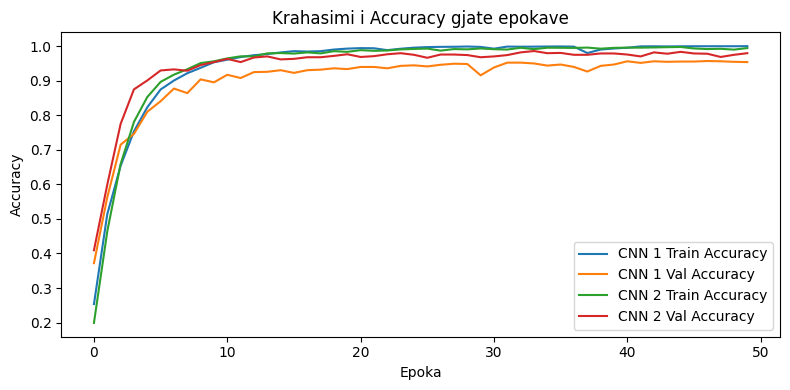

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(history_cnn1.history['accuracy'], label='CNN 1 Train Accuracy')
plt.plot(history_cnn1.history['val_accuracy'], label='CNN 1 Val Accuracy')
plt.plot(history_cnn2.history['accuracy'], label='CNN 2 Train Accuracy')
plt.plot(history_cnn2.history['val_accuracy'], label='CNN 2 Val Accuracy')
plt.title('Krahasimi i Accuracy gjate epokave')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import joblib

from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, normalized_mutual_info_score
)

In [28]:
results_df = pd.DataFrame(results).sort_values(by='F1-score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score
0,CNN Architecture 2,0.986250,0.990234,0.991568,0.990759
1,CNN Architecture 1,0.956875,0.958054,0.946665,0.950406
2,Random Forest,0.917500,0.946108,0.885134,0.906686
3,Logistic Regression + PCA,0.870000,0.866360,0.845793,0.850870
4,Linear SVM + PCA,0.841250,0.867246,0.810141,0.826856
5,KNN + PCA,0.774375,0.802043,0.766144,0.774575


Modeli me i mire: CNN Architecture 2


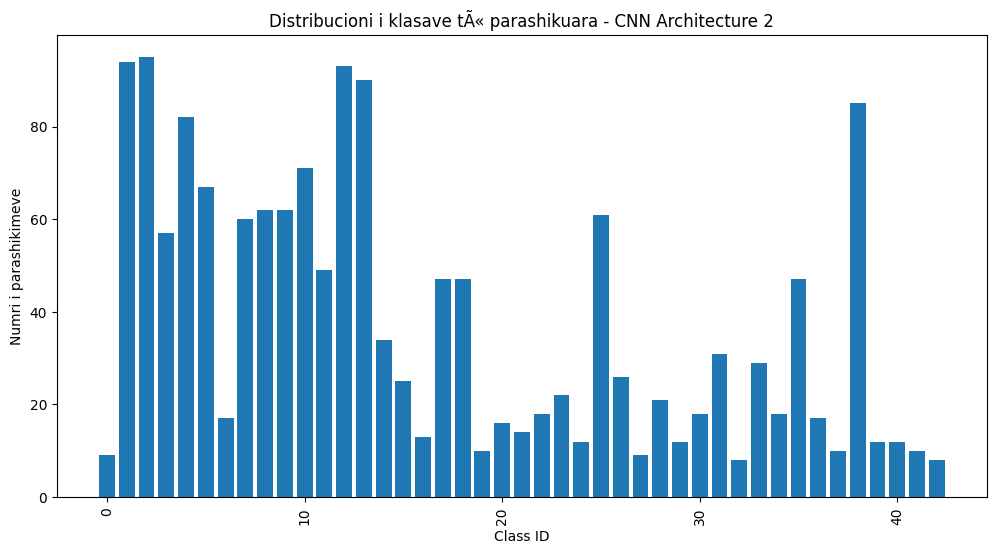

In [29]:
best_model_name = results_df.iloc[0]['Model']
print("Modeli me i mire:", best_model_name)

if best_model_name == 'CNN Architecture 1':
    best_pred = y_pred_cnn1
elif best_model_name == 'CNN Architecture 2':
    best_pred = y_pred_cnn2
elif best_model_name == 'KNN + PCA':
    best_pred = y_pred_knn
elif best_model_name == 'Random Forest':
    best_pred = y_pred_rf
elif best_model_name == 'Logistic Regression + PCA':
    best_pred = y_pred_lr
else:
    best_pred = y_pred_svm

unique, counts = np.unique(best_pred, return_counts=True)

plt.figure(figsize=(12,6))
plt.bar(unique, counts)
plt.title(f'Distribucioni i klasave tÃ« parashikuara - {best_model_name}')
plt.xlabel('Class ID')
plt.ylabel('Numri i parashikimeve')
plt.xticks(rotation=90)
plt.show()


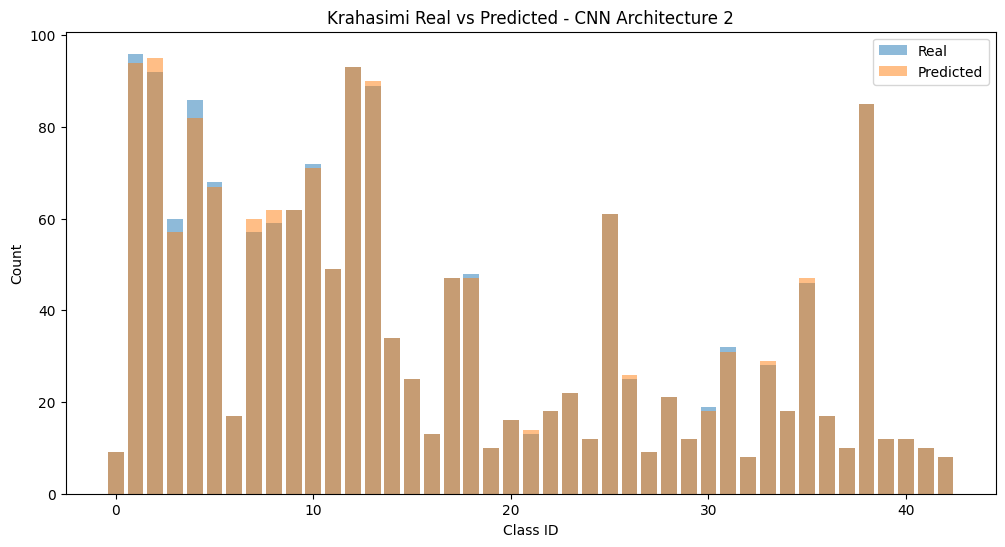

In [30]:
plt.figure(figsize=(12,6))

unique_true, counts_true = np.unique(y_test, return_counts=True)
unique_pred, counts_pred = np.unique(best_pred, return_counts=True)

plt.bar(unique_true, counts_true, alpha=0.5, label='Real')
plt.bar(unique_pred, counts_pred, alpha=0.5, label='Predicted')

plt.title(f'Krahasimi Real vs Predicted - {best_model_name}')
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.legend()
plt.show()

In [31]:
OUTPUT_DIR = Path("saved_models")
OUTPUT_DIR.mkdir(exist_ok=True)

best_model = trained_models[best_model_name]

if best_model_name.startswith('CNN'):
    model_path = OUTPUT_DIR / "best_traffic_sign_model.keras"
    best_model.save(model_path)
else:
    model_path = OUTPUT_DIR / "best_traffic_sign_model.joblib"
    joblib.dump(best_model, model_path)

print("Modeli u ruajt ne:", model_path)


Modeli u ruajt ne: saved_models/best_traffic_sign_model.keras


In [32]:
CLUSTER_SIZE = min(3000, len(X_train_flat))
X_cluster = X_train_flat[:CLUSTER_SIZE]
y_cluster_true = y_train[:CLUSTER_SIZE]

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_cluster_2d = pca_2d.fit_transform(X_cluster)

print("Forma per clustering:", X_cluster_2d.shape)


Forma per clustering: (3000, 2)


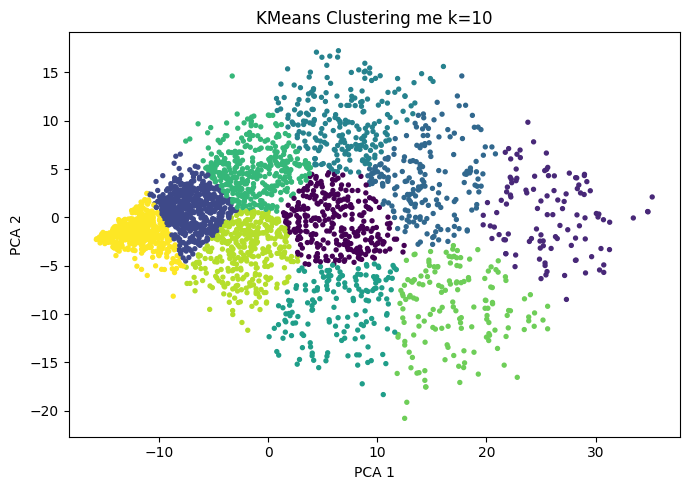

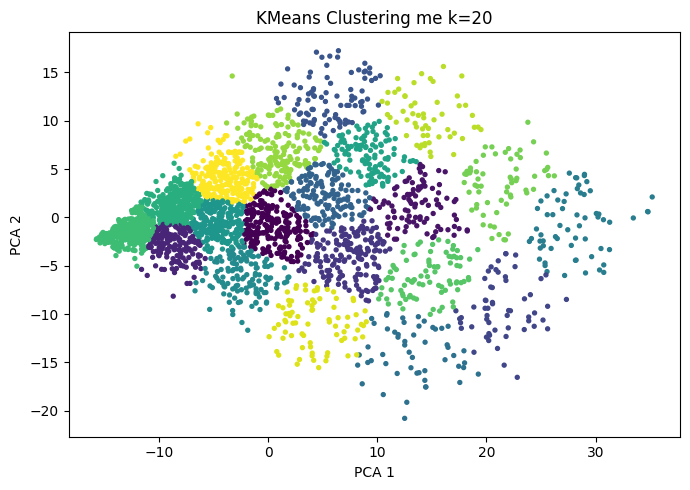

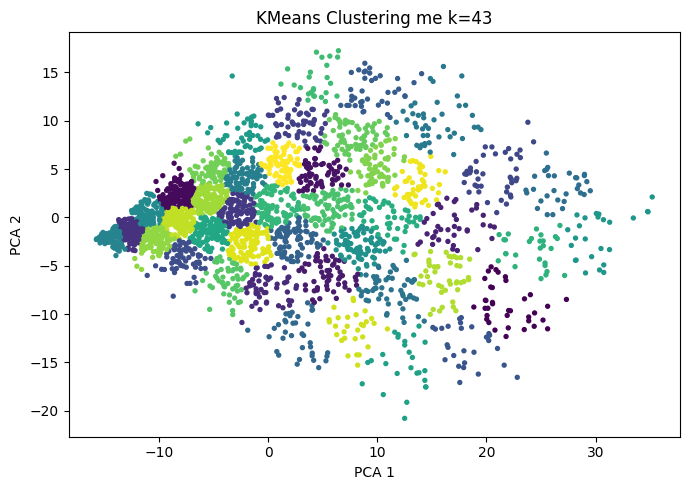

,k,ARI,NMI
0,10,0.019311,0.090621
1,20,0.023188,0.128579
2,43,0.019039,0.174864


In [33]:
cluster_results = []

for k in [10, 20, 43]:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    clusters = kmeans.fit_predict(X_cluster_2d)

    ari = adjusted_rand_score(y_cluster_true, clusters)
    nmi = normalized_mutual_info_score(y_cluster_true, clusters)

    cluster_results.append({
        'k': k,
        'ARI': ari,
        'NMI': nmi
    })

    plt.figure(figsize=(7, 5))
    plt.scatter(X_cluster_2d[:, 0], X_cluster_2d[:, 1], c=clusters, s=8)
    plt.title(f'KMeans Clustering me k={k}')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.tight_layout()
    plt.show()

cluster_results_df = pd.DataFrame(cluster_results)
cluster_results_df


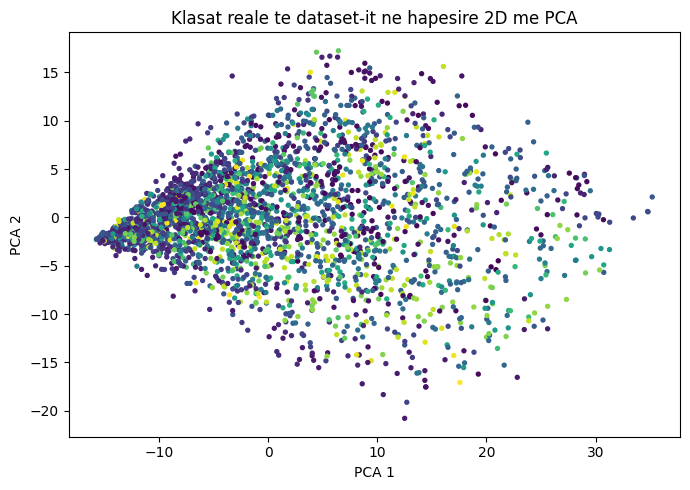

In [34]:
plt.figure(figsize=(7, 5))
plt.scatter(X_cluster_2d[:, 0], X_cluster_2d[:, 1], c=y_cluster_true, s=8)
plt.title('Klasat reale te dataset-it ne hapesire 2D me PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.tight_layout()
plt.show()
